<a href="https://colab.research.google.com/github/Pentaphone/nn_tests/blob/main/nn_test2/nn_test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup

In [47]:
# installs, imports
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2 as transforms

!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("markinsuff/lipophilicity") + "/Lipophilicity.csv"
print("Path to dataset:", path)
print()

!pip install rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors

!pip install py3Dmol
import py3Dmol


# config
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)
batch_size = 64
learning_rate = 1e-3
weight_decay = 1e-4
patience = 3  # epochs, early stopping
limit = 40    # epochs

save_model = True


# util
def rand_index(dataset):
  return torch.randint(0, len(dataset), (1,)).item()

def smiles_to_formula(smiles):
  return rdMolDescriptors.CalcMolFormula(Chem.MolFromSmiles(smiles))

def smiles_to_img(smiles):
  mol = Chem.MolFromSmiles(smiles)
  return Draw.MolToImage(mol)

def smiles_to_3d_obj(smiles):
  mol = Chem.MolFromSmiles(smiles)
  mol = Chem.AddHs(mol)
  AllChem.EmbedMolecule(mol)
  AllChem.MMFFOptimizeMolecule(mol)
  return mol

def smiles_to_fp(smiles):
  mol = Chem.MolFromSmiles(smiles)
  fp = fp_gen.GetFingerprint(mol)

  fp_tensor = torch.zeros(2048)
  for j, bit in enumerate(fp):
    fp_tensor[j] = bit

  return fp_tensor


Using Colab cache for faster access to the 'lipophilicity' dataset.
Path to dataset: /kaggle/input/lipophilicity/Lipophilicity.csv



### Data

In [48]:
# data
class LipophilicityDataset(torch.utils.data.Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
      if torch.is_tensor(i):
        i = i.tolist()

      fp_tensor = smiles_to_fp(self.data.loc[i, "RDKIT_SMILES"])
      exp = self.data.loc[i, "exp"]

      return (fp_tensor, exp)

    def get_data(self):
      return self.data

dataset = LipophilicityDataset(path)

training_data, test_data = torch.utils.data.random_split(dataset, [0.85, 0.15])

training_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

### Data Examples

In [49]:
# data examples structural formulas
# plt.style.use('dark_background')
# plt.figure(figsize=(8, 8))
# for i in range(4):
#     plt.subplot(2, 2, i+1)
#
#     data = pd.read_csv(path)
#     rand_index = torch.randint(0, len(training_data)-4, (1,)).item()
#     smiles = data.loc[rand_index, "RDKIT_SMILES"]
#     formula = smiles_to_formula(smiles)
#     label = data.loc[rand_index, "exp"]
#     image = smiles_to_img(smiles)
#     plt.imshow(image)
#     plt.title(f"{formula}\nLabel: {label}")
#     plt.axis("off")

In [50]:
# data examples 3d objects
data = pd.read_csv(path)

view = py3Dmol.view(viewergrid=(2, 2), width=800, height=800)
view.setBackgroundColor('black')

for i in range(4):
  viewer = (i%2, i//2)
  rand_index = torch.randint(0, len(training_data), (1,)).item()
  mol_3d = smiles_to_3d_obj(data.loc[rand_index, "RDKIT_SMILES"])
  view.addModel(Chem.MolToMolBlock(mol_3d), "mol", viewer=viewer)
  # formula = smiles_to_formula(data.loc[rand_index, "RDKIT_SMILES"])
  label = f"Label: {data.loc[rand_index, 'exp']}"
  view.addLabel(label, {"position":{"x":0,"y":5,"z":0}}, viewer=viewer)
  view.zoomTo()

view.setStyle({
  "stick": {},
  "sphere":{"scale":0.35},
  })

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Model

In [51]:
# model
class NeuralNet(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.net = nn.Sequential(
      nn.Linear(2048, 1024),
      nn.ReLU(),
      nn.BatchNorm1d(1024),
      nn.Dropout(0.2),

      nn.Linear(1024, 512),
      nn.ReLU(),
      nn.BatchNorm1d(512),
      nn.Dropout(0.3),

      nn.Linear(512, 128),
      nn.ReLU(),
      nn.Linear(128, 1)
      )

  def forward(self, x):
        return self.net(x)

model = NeuralNet()


### Training and Testing

Initial Model Performance:
Evaluate
[    0/ 3570]
[  320/ 3570]
[  640/ 3570]
[  960/ 3570]
[ 1280/ 3570]
[ 1600/ 3570]
[ 1920/ 3570]
[ 2240/ 3570]
[ 2560/ 3570]
[ 2880/ 3570]
[ 3200/ 3570]
[ 2750/ 3570]
[ 3570/ 3570]
Average loss (MSE, training data): 6.236557
RMSE: 2.4973099

Evaluate
[    0/  630]
[  320/  630]
[  630/  630]
Average loss (MSE, test data): 6.061318
RMSE: 2.4619743

Eppoch 1/40
loss: 6.383266  [    0/ 3570]
loss: 5.126779  [  320/ 3570]
loss: 2.197887  [  640/ 3570]
loss: 0.927514  [  960/ 3570]
loss: 1.310135  [ 1280/ 3570]
loss: 1.369604  [ 1600/ 3570]
loss: 1.483549  [ 1920/ 3570]
loss: 1.251945  [ 2240/ 3570]
loss: 1.249599  [ 2560/ 3570]
loss: 0.832588  [ 2880/ 3570]
loss: 1.032448  [ 3200/ 3570]
loss: 0.758949  [ 2750/ 3570]

Evaluate
[    0/ 3570]
[  320/ 3570]
[  640/ 3570]
[  960/ 3570]
[ 1280/ 3570]
[ 1600/ 3570]
[ 1920/ 3570]
[ 2240/ 3570]
[ 2560/ 3570]
[ 2880/ 3570]
[ 3200/ 3570]
[ 2750/ 3570]
[ 3570/ 3570]
Average loss (MSE, training data): 0.480287
RMSE:

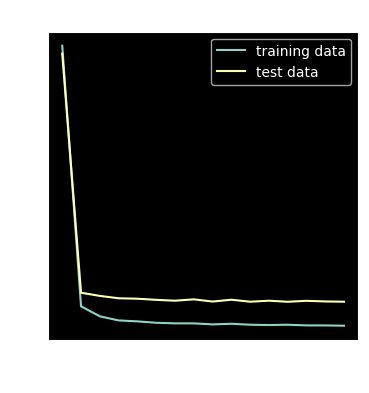

In [52]:
from torch.serialization import save
# training
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

eval_initial_performance = True

def train(dataloader, model, loss_fn, optimizer):
  len_dataset = len(dataloader.dataset)
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    output = model(X)
    y = y.unsqueeze(1).float()
    loss = loss_fn(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 5 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{len_dataset:>5d}]")

  print()

# testing
def evaluate(dataloader, model, loss_fn, dataset_name="test data"):
  print(f"Evaluate")
  len_dataset = len(dataloader.dataset)
  total_loss = 0

  model.eval()
  with torch.no_grad():
    for batch, (X, y) in enumerate(dataloader):
      pred = model(X)
      y = y.unsqueeze(1).float()
      total_loss += loss_fn(pred, y).item()

      if batch % 5 == 0:
        current = batch * len(X)
        print(f"[{current:>5d}/{len_dataset:>5d}]")

    total_loss = total_loss / len(dataloader)
    rmse = total_loss**0.5

  print(f"[{len_dataset:>5d}/{len_dataset:>5d}]")
  print(f"Average loss (MSE, {dataset_name}): {total_loss:>8f}\nRMSE: {rmse:.7f}\n")

  return total_loss


# training cycle
training_evals = []
test_evals = []
best_test_loss = 0.0
epochs_without_improvement = 0

if eval_initial_performance:
  print("Initial Model Performance:")
  training_evals.append(evaluate(training_loader, model, loss_fn, dataset_name="training data"))
  test_loss = evaluate(test_loader, model, loss_fn, dataset_name="test data")
  test_evals.append(test_loss)
  best_test_loss = test_loss

for epoch in range(limit):
  print(f"Eppoch {epoch+1}/{limit}")
  train(training_loader, model, loss_fn, optimizer)

  training_evals.append(evaluate(training_loader, model, loss_fn, dataset_name="training data"))
  test_loss = evaluate(test_loader, model, loss_fn, dataset_name="test data")
  test_evals.append(test_loss)

  if test_loss < best_test_loss:
    best_test_loss = test_loss
    epochs_without_improvement = 0
  else:
    epochs_without_improvement += 1

  if epochs_without_improvement >= patience:
    print(f"Early stopping after epoch {epoch}")
    break

print("Training and testing completed")


# total parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params}\n')

# plot
plt.figure(figsize=(4, 4))
plt.style.use('dark_background')
plt.title("Training and Testing Loss")
plt.plot(training_evals, label="training data")
plt.plot(test_evals, label="test data")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# save model
if save_model:
  torch.save(model.state_dict(), 'model_weights.pth')
  torch.save(model, 'model.pth')
  print("Model saved")

### Prediction Example

In [58]:
def pred_example(model, dataset, i=None, visualization="3d_object"):
  if visualization not in ["structural", "3d_object", "none"]:
    raise ValueError("Visualization must be either 'structural' or '3d_object'")

  model.eval()

  # dataset argument is a Subset (like test_data). A Subset object does not have get_data(), but its underlying full dataset does.
  full_data = dataset.dataset.get_data()

  if i is None:
    idx_within_subset = torch.randint(0, len(dataset), (1,)).item()
    idx_within_full_data = dataset.indices[idx_within_subset]
  else:
    idx_within_full_data = i

  smiles = full_data.loc[idx_within_full_data, "RDKIT_SMILES"]

  ground_truth = full_data.loc[idx_within_full_data, "exp"]

  fp_tensor = smiles_to_fp(smiles)
  pred = model(fp_tensor.unsqueeze(0)).squeeze(0).item()
  error = pred - ground_truth

  match visualization:
    case "structural":
      image = smiles_to_img(smiles)
      plt.figure(figsize=(4,4))
      plt.axis("off")
      plt.imshow(image)
      plt.show()

    case "3d_object":
      mol_3d = smiles_to_3d_obj(smiles)
      view = py3Dmol.view(width=600, height=600)
      view.setBackgroundColor('black')
      view.addModel(Chem.MolToMolBlock(mol_3d), "mol")
      view.setStyle({
        "stick": {},
        "sphere":{"scale":0.35},
        })
      view.zoomTo()
      view.show()

    case "none":
      pass

  formula = smiles_to_formula(smiles)
  print(
f'''{formula}
Predicted: {pred:.2f}
Ground Truth: {ground_truth}
Error: {error:.3f}'''
      )

pred_example(model, test_data)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

C36H41Cl2N5O4
Predicted: 2.63
Ground Truth: 2.78
Error: -0.152
